In [1]:
import h5py
from collections import defaultdict

def load_h5py_file(file_path: str) -> dict:
    data = defaultdict(list)
    
    with h5py.File(file_path, 'r') as f:
        trials = list(f.keys())
        for trial in trials:
            g = f[trial]

            data['neural_features'].append(g['input_features'][:])
            data['n_time_steps'].append(g.attrs['n_time_steps'])
            data['seq_class_ids'].append(g['seq_class_ids'][:] if 'seq_class_ids' in g else None)
            data['seq_len'].append(g.attrs['seq_len'] if 'seq_len' in g.attrs else None)
            data['transcriptions'].append(g['transcription'][:] if 'transcription' in g else None)
            data['sentence_label'].append(g.attrs['sentence_label'][:] if 'sentence_label' in g.attrs else None)
            data['session'].append(g.attrs['session'])
            data['block_num'].append(g.attrs['block_num'])
            data['trial_num'].append(g.attrs['trial_num'])
    
    return dict(data)

In [2]:
data = load_h5py_file("/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.13/data_train.hdf5")

# Utils

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
from scipy.ndimage import gaussian_filter1d

def gauss_smooth(inputs, device, smooth_kernel_std=2, smooth_kernel_size=100,  padding='same'):
    """
    Applies a 1D Gaussian smoothing operation with PyTorch to smooth the data along the time axis.
    Args:
        inputs (tensor : B x T x N): A 3D tensor with batch size B, time steps T, and number of features N.
                                     Assumed to already be on the correct device (e.g., GPU).
        kernelSD (float): Standard deviation of the Gaussian smoothing kernel.
        padding (str): Padding mode, either 'same' or 'valid'.
        device (str): Device to use for computation (e.g., 'cuda' or 'cpu').
    Returns:
        smoothed (tensor : B x T x N): A smoothed 3D tensor with batch size B, time steps T, and number of features N.
    """
    # Get Gaussian kernel
    inp = np.zeros(smooth_kernel_size, dtype=np.float32)
    inp[smooth_kernel_size // 2] = 1
    gaussKernel = gaussian_filter1d(inp, smooth_kernel_std)
    validIdx = np.argwhere(gaussKernel > 0.01)
    gaussKernel = gaussKernel[validIdx]
    gaussKernel = np.squeeze(gaussKernel / np.sum(gaussKernel))

    # Convert to tensor
    gaussKernel = torch.tensor(gaussKernel, dtype=torch.float32, device=device)
    gaussKernel = gaussKernel.view(1, 1, -1)  # [1, 1, kernel_size]

    # Prepare convolution
    B, T, C = inputs.shape
    inputs = inputs.permute(0, 2, 1)  # [B, C, T]
    gaussKernel = gaussKernel.repeat(C, 1, 1)  # [C, 1, kernel_size]

    # Perform convolution
    smoothed = F.conv1d(inputs, gaussKernel, padding=padding, groups=C)
    
    return smoothed.permute(0, 2, 1)  # [B, T, C]

In [4]:
def transform_data(features, n_time_steps, mode = 'train', device='cpu'):
    '''
    Apply various augmentations and smoothing to data
    Performing augmentations is much faster on GPU than CPU
    '''

    transform_args = {
        'white_noise_std': 1.0, # standard deviation of the white noise added to the data
        'constant_offset_std': 0.2, # standard deviation of the constant offset added to the data
        'random_walk_std': 0.0, # standard deviation of the random walk added to the data
        'random_walk_axis': -1, # axis along which the random walk is applied
        'static_gain_std': 0.0, # standard deviation of the static gain applied to the data
        'random_cut': 3, # number of time steps to randomly cut from the beginning of each batch of trials
        'smooth_kernel_size': 100, # size of the smoothing kernel applied to the data
        'smooth_data': True, # whether to smooth the data
        'smooth_kernel_std': 2, # standard deviation of the smoothing kernel applied to the data                     
    }

    data_shape = features.shape
    batch_size = data_shape[0]
    channels = data_shape[-1]

    # We only apply these augmentations in training
    if mode == 'train':

        # add static gain noise 
        if transform_args['static_gain_std'] > 0:
            warp_mat = torch.tile(torch.unsqueeze(torch.eye(channels), dim = 0), (batch_size, 1, 1))
            warp_mat += torch.randn_like(warp_mat, device=device) * transform_args['static_gain_std']

            features = torch.matmul(features, warp_mat)

        # add white noise
        if transform_args['white_noise_std'] > 0:
            features += torch.randn(data_shape, device=device) * transform_args['white_noise_std']

        # add constant offset noise 
        if transform_args['constant_offset_std'] > 0:
            features += torch.randn((batch_size, 1, channels), device=device) * transform_args['constant_offset_std']

        # add random walk noise
        if transform_args['random_walk_std'] > 0:
            features += torch.cumsum(torch.randn(data_shape, device=device) * transform_args['random_walk_std'], dim = transform_args['random_walk_axis'])

        # randomly cutoff part of the data timecourse
        if transform_args['random_cut'] > 0:
            cut = np.random.randint(0, transform_args['random_cut'])
            features = features[:, cut:, :]
            n_time_steps = n_time_steps - cut

    # Apply Gaussian smoothing to data 
    # This is done in both training and validation
    if transform_args['smooth_data']:
        features = gauss_smooth(
            inputs = features, 
            device = device,
            smooth_kernel_std = transform_args['smooth_kernel_std'],
            smooth_kernel_size= transform_args['smooth_kernel_size'],
            padding='valid'
            )
    
    return features, n_time_steps

# GRU Decoder

In [5]:
import torch 
from torch import nn

class GRUDecoder(nn.Module):
    '''
    Defines the GRU decoder

    This class combines day-specific input layers, a GRU, and an output classification layer
    '''
    def __init__(self,
                 neural_dim,
                 n_units,
                 n_days,
                 n_classes,
                 rnn_dropout = 0.0,
                 input_dropout = 0.0,
                 n_layers = 5, 
                 patch_size = 0,
                 patch_stride = 0,
                 ):
        '''
        neural_dim  (int)      - number of channels in a single timestep (e.g. 512)
        n_units     (int)      - number of hidden units in each recurrent layer - equal to the size of the hidden state
        n_days      (int)      - number of days in the dataset
        n_classes   (int)      - number of classes 
        rnn_dropout    (float) - percentage of units to droupout during training
        input_dropout (float)  - percentage of input units to dropout during training
        n_layers    (int)      - number of recurrent layers 
        patch_size  (int)      - the number of timesteps to concat on initial input layer - a value of 0 will disable this "input concat" step 
        patch_stride(int)      - the number of timesteps to stride over when concatenating initial input 
        '''
        super(GRUDecoder, self).__init__()
        
        self.neural_dim = neural_dim
        self.n_units = n_units
        self.n_classes = n_classes
        self.n_layers = n_layers 
        self.n_days = n_days

        self.rnn_dropout = rnn_dropout
        self.input_dropout = input_dropout
        
        self.patch_size = patch_size
        self.patch_stride = patch_stride

        # Parameters for the day-specific input layers
        self.day_layer_activation = nn.Softsign() # basically a shallower tanh 

        # Set weights for day layers to be identity matrices so the model can learn its own day-specific transformations
        self.day_weights = nn.ParameterList(
            [nn.Parameter(torch.eye(self.neural_dim)) for _ in range(self.n_days)]
        )
        self.day_biases = nn.ParameterList(
            [nn.Parameter(torch.zeros(1, self.neural_dim)) for _ in range(self.n_days)]
        )

        self.day_layer_dropout = nn.Dropout(input_dropout)
        
        self.input_size = self.neural_dim

        # If we are using "strided inputs", then the input size of the first recurrent layer will actually be in_size * patch_size
        if self.patch_size > 0:
            self.input_size *= self.patch_size

        self.gru = nn.GRU(
            input_size = self.input_size,
            hidden_size = self.n_units,
            num_layers = self.n_layers,
            dropout = self.rnn_dropout, 
            batch_first = True, # The first dim of our input is the batch dim
            bidirectional = False,
        )

        # Set recurrent units to have orthogonal param init and input layers to have xavier init
        for name, param in self.gru.named_parameters():
            if "weight_hh" in name:
                nn.init.orthogonal_(param)
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param)

        # Prediciton head. Weight init to xavier
        self.out = nn.Linear(self.n_units, self.n_classes)
        nn.init.xavier_uniform_(self.out.weight)

        # Learnable initial hidden states
        self.h0 = nn.Parameter(nn.init.xavier_uniform_(torch.zeros(1, 1, self.n_units)))

    def forward(self, x, day_idx, states = None, return_state = False):
        '''
        x        (tensor)  - batch of examples (trials) of shape: (batch_size, time_series_length, neural_dim)
        day_idx  (tensor)  - tensor which is a list of day indexs corresponding to the day of each example in the batch x. 
        '''

        # Apply day-specific layer to (hopefully) project neural data from the different days to the same latent space
        day_weights = torch.stack([self.day_weights[i] for i in day_idx], dim=0)
        day_biases = torch.cat([self.day_biases[i] for i in day_idx], dim=0).unsqueeze(1)

        x = torch.einsum("btd,bdk->btk", x, day_weights) + day_biases
        x = self.day_layer_activation(x)

        # Apply dropout to the ouput of the day specific layer
        if self.input_dropout > 0:
            x = self.day_layer_dropout(x)

        # (Optionally) Perform input concat operation
        if self.patch_size > 0: 
  
            x = x.unsqueeze(1)                      # [batches, 1, timesteps, feature_dim]
            x = x.permute(0, 3, 1, 2)               # [batches, feature_dim, 1, timesteps]
            
            # Extract patches using unfold (sliding window)
            x_unfold = x.unfold(3, self.patch_size, self.patch_stride)  # [batches, feature_dim, 1, num_patches, patch_size]
            
            # Remove dummy height dimension and rearrange dimensions
            x_unfold = x_unfold.squeeze(2)           # [batches, feature_dum, num_patches, patch_size]
            x_unfold = x_unfold.permute(0, 2, 3, 1)  # [batches, num_patches, patch_size, feature_dim]

            # Flatten last two dimensions (patch_size and features)
            x = x_unfold.reshape(x.size(0), x_unfold.size(1), -1) 
        
        # Determine initial hidden states
        if states is None:
            states = self.h0.expand(self.n_layers, x.shape[0], self.n_units).contiguous()

        # Pass input through RNN 
        output, hidden_states = self.gru(x, states)

        # Compute logits
        logits = self.out(output)
        
        if return_state:
            return logits, hidden_states
        
        return logits

# LSTM Decoder

In [6]:
class LSTMDecoder(nn.Module):
    '''
    Defines the LSTM decoder

    This class combines day-specific input layers, an LSTM, and an output classification layer
    '''
    def __init__(self,
                 neural_dim,
                 n_units,
                 n_days,
                 n_classes,
                 rnn_dropout=0.0,
                 input_dropout=0.0,
                 n_layers=5,
                 patch_size=0,
                 patch_stride=0):
        super(LSTMDecoder, self).__init__()
        
        self.neural_dim = neural_dim
        self.n_units = n_units
        self.n_classes = n_classes
        self.n_layers = n_layers 
        self.n_days = n_days

        self.rnn_dropout = rnn_dropout
        self.input_dropout = input_dropout
        
        self.patch_size = patch_size
        self.patch_stride = patch_stride

        # Day-specific linear transformations
        self.day_layer_activation = nn.Softsign()
        self.day_weights = nn.ParameterList(
            [nn.Parameter(torch.eye(self.neural_dim)) for _ in range(self.n_days)]
        )
        self.day_biases = nn.ParameterList(
            [nn.Parameter(torch.zeros(1, self.neural_dim)) for _ in range(self.n_days)]
        )

        self.day_layer_dropout = nn.Dropout(input_dropout)
        
        self.input_size = self.neural_dim
        if self.patch_size > 0:
            self.input_size *= self.patch_size

        # --- LSTM instead of GRU ---
        self.lstm = nn.LSTM(
            input_size=self.input_size,
            hidden_size=self.n_units,
            num_layers=self.n_layers,
            dropout=self.rnn_dropout,
            batch_first=True,
            bidirectional=False,
        )

        # Initialize weights (same logic as before)
        for name, param in self.lstm.named_parameters():
            if "weight_hh" in name:
                nn.init.orthogonal_(param)
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param)

        # Output layer
        self.out = nn.Linear(self.n_units, self.n_classes)
        nn.init.xavier_uniform_(self.out.weight)

        # Learnable initial hidden and cell states
        self.h0 = nn.Parameter(torch.zeros(1, 1, self.n_units))
        self.c0 = nn.Parameter(torch.zeros(1, 1, self.n_units))

    def forward(self, x, day_idx, states=None, return_state=False):
        '''
        x        (tensor)  - (batch_size, time_series_length, neural_dim)
        day_idx  (tensor)  - list of day indices corresponding to each example
        '''
        # --- Apply day-specific transformations ---
        day_weights = torch.stack([self.day_weights[i] for i in day_idx], dim=0)
        day_biases = torch.cat([self.day_biases[i] for i in day_idx], dim=0).unsqueeze(1)
        x = torch.einsum("btd,bdk->btk", x, day_weights) + day_biases
        x = self.day_layer_activation(x)

        if self.input_dropout > 0:
            x = self.day_layer_dropout(x)

        # --- Optional strided patching ---
        if self.patch_size > 0:
            x = x.unsqueeze(1)                      # [b, 1, t, d]
            x = x.permute(0, 3, 1, 2)               # [b, d, 1, t]
            x_unfold = x.unfold(3, self.patch_size, self.patch_stride)  # [b, d, 1, n_patches, patch_size]
            x_unfold = x_unfold.squeeze(2).permute(0, 2, 3, 1)          # [b, n_patches, patch_size, d]
            x = x_unfold.reshape(x.size(0), x_unfold.size(1), -1)       # [b, n_patches, patch_size*d]

        # --- Initial states ---
        if states is None:
            h0 = self.h0.expand(self.n_layers, x.shape[0], self.n_units).contiguous()
            c0 = self.c0.expand(self.n_layers, x.shape[0], self.n_units).contiguous()
        else:
            h0, c0 = states

        # --- Forward pass through LSTM ---
        output, (hn, cn) = self.lstm(x, (h0, c0))

        # --- Output classification ---
        logits = self.out(output)

        if return_state:
            return logits, (hn, cn)

        return logits


# Transformer

In [7]:
class Transformer(nn.Module):
    def __init__(
        self,
        neural_dim=512,
        d_model=256,
        nhead=8,
        num_encoder_layers=4,
        dim_feedforward=1024,
        dropout=0.1,
        n_days=45,
        n_classes=41,
    ):
        super().__init__()

        self.d_model = d_model

        self.day_weights = nn.ParameterList(
            [nn.Parameter(torch.eye(neural_dim)) for _ in range(n_days)]
        )
        self.day_biases = nn.ParameterList(
            [nn.Parameter(torch.zeros(1, neural_dim)) for _ in range(n_days)]
        )
        self.day_activation = nn.Softsign()

        self.input_projection = nn.Linear(neural_dim, d_model)

        self.pos_encoder = PositionalEncoding(d_model, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_encoder_layers
        )

        self.output_projection = nn.Linear(d_model, n_classes)

    def forward(self, x, day_idx):
        day_weights = torch.stack([self.day_weights[i] for i in day_idx], dim=0)
        day_biases = torch.cat([self.day_biases[i] for i in day_idx], dim=0).unsqueeze(
            1
        )
        x = torch.einsum("btd,bdk->btk", x, day_weights) + day_biases
        x = self.day_activation(x)

        x = self.input_projection(x)

        # add positional encoding
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)

        # project to phoneme logits
        logits = self.output_projection(x)

        return logits


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)

# CNN + Transformer

In [8]:
class EEGFeatureExtractor(nn.Module):
    """
    CNN-based feature extractor for EEG data to learn EEG patterns, oscillations, etc.
    Reduces dimensionality before transformer input by mapping raw signal to a lower dimension feature space.
    """

    def __init__(self, in_features, feature_dim=256):
        super().__init__()
        network = nn.Sequential(
            # layer 1: downsample by 2, output 128 channels - capture local patterns
            nn.Conv1d(in_features, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128), # batch normalization for stable training
            nn.GELU(), # smooth non-linearity - better than Relu for continuous EEG signal

            # layer 2: downsample by 2, output 256 channels - capture broader patterns
            nn.Conv1d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(256), # batch normalization for stable training
            nn.GELU(), # smooth non-linearity - better than Relu for continuous EEG signal

            # layer 3: no downsampling, output feature_dim channels - final feature representation
            nn.Conv1d(256, feature_dim, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(feature_dim), # batch normalization for stable training
            nn.GELU(), # smooth non-linearity - better than Relu for continuous EEG signal
        )

        self.net = network

    def forward(self, x):
        # input: (B, T, D) 
        x = x.permute(0, 2, 1)  # → (B, D, T) network swaps time and feature dims
        x = self.net(x) 
        x = x.permute(0, 2, 1)  # → (B, reduced_T, feature_dim) to original format
        return x
    

class CTCDecoder(nn.Module):
    def __init__(self, d_model=256, vocab_size=60):
        super().__init__()
        self.fc = nn.Linear(d_model, vocab_size) # fully connected layer to map to vocab size

    def forward(self, x):
        # x: (B, T, d_model)
        return self.fc(x)  # (B, T, vocab_size)
    
class LearnedPositionalEncoding(nn.Module):
    """Learned positional embeddings for temporal sequences."""
    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        self.pe = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
        self.max_len = max_len
        self.d_model = d_model

    def forward(self, x):
        # Extend positional embeddings if sequence is longer than expected
        if x.size(1) > self.max_len:
            extra = x.size(1) - self.max_len
            extra_pe = nn.Parameter(torch.randn(1, extra, self.d_model) * 0.02).to(x.device)
            self.pe = nn.Parameter(torch.cat([self.pe, extra_pe], dim=1))
            self.max_len = x.size(1)
        return x + self.pe[:, :x.size(1), :]


class TemporalTransformer(nn.Module):
    """
    Transformer model for EEG feature modeling.

    Args:
      neural_dim:   EEG feature dimension per timestep
      d_model:      transformer embedding dimension
      n_days:       number of days data was recorded on
      n_tokens:     number of output tokens
      n_layers:     number of transformer layers
      n_heads:      number of attention heads - to sum to d_model, d_model must be dividable by n_heads
      ff_mult:      feedforward expansion factor
      dropout:      dropout probability
      patch_stride: stride for patching input (0 for no stride)
      max_seq_len:  maximum sequence length to tokenize
    """

    def __init__(self,
                 neural_dim,
                 d_model,
                 n_days,
                 n_tokens,
                 n_layers=6,
                 n_heads=8,
                 ff_mult=4,
                 dropout=0.1,
                 patch_stride=0,
                 max_seq_len=2048):

        super().__init__()

        self.neural_dim = neural_dim
        self.d_model = d_model
        self.n_days = n_days
        self.n_tokens = n_tokens
        self.patch_stride = patch_stride
        self.input_size = self.neural_dim

        # need to allow for cross session variability and training by day 
        # day specific data input layers
        self.day_layer_activation = nn.Softsign() # non linear scaling for day specific layers
        self.day_weights = nn.ParameterList(
            [nn.Parameter(torch.eye(self.neural_dim)) for _ in range(self.n_days)]
        )
        self.day_biases = nn.ParameterList(
            [nn.Parameter(torch.zeros(1, self.neural_dim)) for _ in range(self.n_days)]
        )
        # dropout for day-specific layers (in between layers) - prevent overfitting to day specific features
        self.day_dropout = nn.Dropout(dropout)
        
        # input projection to d_model dimensions
        self.input_proj = nn.Linear(self.input_size, self.d_model)
        nn.init.xavier_uniform_(self.input_proj.weight)

        # encoding of positional information
        self.pos_encoder = LearnedPositionalEncoding(max_seq_len, self.d_model) # maps time steps to d_model dimension space

        # transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=n_heads,
            dim_feedforward=self.d_model * ff_mult,
            dropout=dropout,
            activation="gelu", # gaussian error linear unit - transformers use soft attention, so relu can be too harsh (hard attention)
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # output classification
        self.out = nn.Linear(self.d_model, self.n_tokens)

        # initialize output layer to be uniform (based on number of input and output units layers)
        nn.init.xavier_uniform_(self.out.weight)

        # add final dropout layer if we have dropout
        self.final_dropout = nn.Dropout(dropout)

    def forward(self, x, day_idx): # should work with batch input from nejm
        """
        x: (batch, time, neural_dim)
        day_idx: tensor of shape (batch,) with day indices [0..n_days-1]
        """
        device = x.device # set device to use for tensors

        day_weights = torch.stack([self.day_weights[int(i)] for i in day_idx], dim=0).to(device)
        day_biases = torch.cat([self.day_biases[int(i)] for i in day_idx], dim=0).unsqueeze(1).to(device)
        
        x = torch.einsum("btd,bdk->btk", x, day_weights) + day_biases # eigensum for batch matrix multiplication
        x = self.day_layer_activation(x) 
        x = self.day_dropout(x)

        # project batch dimension input to d_model (embedder) dimension
        x = self.input_proj(x)

        # add positional encoding to map time steps to d_model space
        x = self.pos_encoder(x)

        # pass to transformer encoder
        x = self.encoder(x)
        x = self.final_dropout(x) # dropout in final fully connected layer

        # output classification - map to output tokens
        logits = self.out(x)  # (batch, time, n_classes)
        return logits
    
class EEGToTextModel(nn.Module):
    def __init__(self,
                 in_features,
                 vocab_size,
                 d_model=256,
                 n_days=45,
                 n_tokens=None,
                 n_layers=6,
                 n_heads=8,
                 ff_mult=4,
                 dropout=0.1,
                 patch_stride=0,
                 max_seq_len=2048,
                 feature_dim=256):
        super().__init__()
        
        # Feature extractor maps EEG features to transformer embedding space
        self.feature_extractor = EEGFeatureExtractor(in_features, feature_dim=feature_dim)

        # Temporal encoder models temporal dependencies across timesteps
        self.temporal_encoder = TemporalTransformer(
            neural_dim=feature_dim,
            d_model=d_model,
            n_days=n_days,
            n_tokens=n_tokens if n_tokens is not None else vocab_size,
            n_layers=n_layers,
            n_heads=n_heads,
            ff_mult=ff_mult,
            dropout=dropout,
            patch_stride=patch_stride,
            max_seq_len=max_seq_len
        )

        # Decoder converts encoded sequence into text logits
        self.decoder = CTCDecoder(d_model=d_model, vocab_size=vocab_size)

    def forward(self, input_features, day_idx):
        x = self.feature_extractor(input_features)
        x = self.temporal_encoder(x, day_idx)
        logits = self.decoder(x)
        return logits

# EEG Conformer

In [9]:
from einops.layers.torch import Rearrange

# Convolution module
# use conv to capture local features, instead of postion embedding.
class PatchEmbedding(nn.Module):
    """
    Convert (B, T, F) -> (B, T//time_pool, E)
    Designed to preserve time resolution by using convs that operate across features
    and downsample the time axis in a controlled way.
    """
    def __init__(self, n_features=512, emb_size=64, time_pool=4, kernel_size=[7,3]):
        super().__init__()
        self.time_pool = time_pool
        layers = []

        layers.extend([
            nn.Conv1d(n_features, emb_size, kernel_size=kernel_size[0], stride=1, padding=3),
            nn.BatchNorm1d(emb_size),
            nn.ELU(),
        ])
        
        for size in kernel_size[1:-1]:
            layers.extend([
                nn.Conv1d(emb_size, emb_size, kernel_size=size, stride=1, 
                         padding=size//2),
                nn.BatchNorm1d(emb_size),
                nn.ELU(),
            ])

        layers.append(
            nn.Conv1d(emb_size, emb_size, kernel_size=kernel_size[-1], stride=time_pool, padding=1)
        )
        self.proj = nn.Sequential(*layers)

        print(f"PatchEmbedding with {len(layers)} layers")

    def forward(self, x):
        # x: (B, T, F)
        x = x.transpose(1, 2)  # (B, F, T)
        x = self.proj(x)       # (B, E, T//time_pool)
        x = x.transpose(1, 2)  # (B, T//time_pool, E)
        return x

class EEGConformer(nn.Module):
    def __init__(
        self,
        neural_dim=512,
        d_model=64,
        nhead=1,
        num_encoder_layers=1,
        dim_feedforward=256,
        dropout=0.1,
        n_days=45,
        n_classes=41,
        time_pool=4,
        kernel_size=[7,3],
    ):
        super().__init__()
        self.d_model = d_model
        self.time_pool = time_pool
        self.n_classes = n_classes
        self.patch = PatchEmbedding(n_features=neural_dim, emb_size=d_model, time_pool=time_pool, kernel_size=kernel_size)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_encoder_layers
        )
        self.output_projection = nn.Linear(d_model, n_classes)

    def forward(self, x, day_idx):
        # x: (B, T, 512)
        x = self.patch(x)  # (B, T//time_pool, d_model)
        x = self.transformer_encoder(x)
        logits = self.output_projection(x)  # (B, T//time_pool, n_classes)
        return logits

# Dataset

In [10]:
from pathlib import Path

import h5py
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset


class BrainToTextDataset(Dataset):
    def __init__(
        self,
        data_dir: str,
        dataset_key: str = "train",
        max_sessions: int = None,
    ):
        if dataset_key in ["train", "val", "test"]:
            all_paths = sorted(Path(data_dir).rglob(f"*/data_{dataset_key}.hdf5"))
            
            if max_sessions is not None:
                self.file_paths = all_paths[:max_sessions]
            else:
                self.file_paths = all_paths
        else:
            self.file_paths = []

        self.session_info = []
        self.total_trials = None
        self._load_session_info()

    def _load_session_info(self) -> None:
        total_trials = 0

        for day_idx, path in enumerate(self.file_paths):
            with h5py.File(path, "r") as f:
                num_trials = len(list(f.keys()))
                self.session_info.append(
                    {
                        "day_idx": day_idx,
                        "file_path": path,
                        "num_trials": num_trials,
                        "trial_offset": total_trials,
                    }
                )
                total_trials += num_trials

        self.total_trials = total_trials

    def __len__(self):
        return self.total_trials

    def __getitem__(self, idx):
        for s in self.session_info:
            if idx < s["trial_offset"] + s["num_trials"]:
                trial_idx = idx - s["trial_offset"]
                day_idx = s["day_idx"]
                file_path = s["file_path"]
                break

        with h5py.File(file_path, "r") as f:
            trial_key = f"trial_{trial_idx:04d}"
            g = f[trial_key]

            return {
                "input_features": torch.from_numpy(g["input_features"][:]).float(),
                "seq_class_ids": torch.from_numpy(g["seq_class_ids"][:]).long(),
                "phone_seq_lens": g.attrs["seq_len"],
                "n_time_steps": g.attrs["n_time_steps"],
                "day_idx": day_idx,
            }


def collate_fn(batch: list) -> dict:
    return {
        "input_features": pad_sequence(
            [b["input_features"] for b in batch], batch_first=True
        ),
        "seq_class_ids": pad_sequence(
            [b["seq_class_ids"] for b in batch], batch_first=True
        ),
        "phone_seq_lens": torch.tensor([b["phone_seq_lens"] for b in batch]),
        "n_time_steps": torch.tensor([b["n_time_steps"] for b in batch]),
        "day_idxs": torch.tensor([b["day_idx"] for b in batch]),
    }

# Train loop

In [11]:
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm


def train_step(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim,
    device: torch.device,
) -> float:
    model.train()
    total_loss = 0
    ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)

    pbar = tqdm(dataloader, desc="Training", leave=False)

    for batch in pbar:
        features = batch["input_features"].to(device)
        labels = batch["seq_class_ids"].to(device)
        n_time_steps = batch["n_time_steps"].to(device)
        phone_seq_lens = batch["phone_seq_lens"].to(device)
        day_indicies = batch["day_idxs"].to(device)

        # smooth neural data
        #features_smooth = gauss_smooth(
        #    features,
        #    device,
        #    smooth_kernel_std=2,
        #    smooth_kernel_size=100,
        #    padding="valid",
        #)

        features_aug, n_time_steps = transform_data(features, n_time_steps, 'train', device=device)

        if isinstance(model,EEGConformer):
            adjusted_lens = (n_time_steps - 100 + 1) // model.time_pool
        else:
            adjusted_lens = n_time_steps - 100 + 1

        #logits = model(features_smooth, day_idx=day_indicies)
        logits = model(features_aug, day_idx=day_indicies)
        

        # CTC Loss
        log_probs = logits.log_softmax(2).permute(1, 0, 2)
        loss = ctc_loss(log_probs, labels, adjusted_lens, phone_seq_lens)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        batch_loss = loss.item()
        total_loss += batch_loss
        pbar.set_postfix({"loss": f"{batch_loss:.4f}"})

    return total_loss / len(dataloader)


def save_checkpoint(
    model: nn.Module,
    optimizer: torch.optim,
    epoch: int,
    val_per: float,
    save_path: Path,
) -> None:
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_per": val_per,
    }
    torch.save(checkpoint, save_path)

    print(f"Checkpoint saved to {save_path}")


def load_checkpoint(
    model: nn.Module,
    optimizer: torch.optim,
    checkpoint_path: Path,
) -> tuple:
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    epoch = checkpoint["epoch"]
    val_per = checkpoint["val_per"]

    print(f"Loaded checkpoint from epoch {epoch}, PER: {val_per:.4f}")

    return epoch, val_per


def evaluate(model: nn.Module, 
             dataloader: DataLoader, 
             device: torch.device,
            ) -> tuple:
    model.eval()
    total_loss = 0
    total_edit_distance = 0
    total_phonemes = 0
    ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)

    pbar = tqdm(dataloader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for batch in pbar:
            features = batch["input_features"].to(device)
            labels = batch["seq_class_ids"].to(device)
            n_time_steps = batch["n_time_steps"].to(device)
            phone_seq_lens = batch["phone_seq_lens"].to(device)
            day_indicies = batch["day_idxs"].to(device)

            features_smooth = gauss_smooth(
                features,
                device,
                smooth_kernel_std=2,
                smooth_kernel_size=100,
                padding="valid",
            )

            if isinstance(model,EEGConformer):
                adjusted_lens = (n_time_steps - 100 + 1) // model.time_pool
            else:
                adjusted_lens = n_time_steps - 100 + 1


            logits = model(features_smooth, day_idx=day_indicies)

            log_probs = logits.log_softmax(2).permute(1, 0, 2)
            loss = ctc_loss(log_probs, labels, adjusted_lens, phone_seq_lens)
            total_loss += loss.item()

            for i in range(logits.shape[0]):
                pred_seq = torch.argmax(logits[i, : adjusted_lens[i]], dim=-1)
                pred_seq = torch.unique_consecutive(pred_seq)
                pred_seq = pred_seq[pred_seq != 0]

                true_seq = labels[i, : phone_seq_lens[i]]

                edit_dist = edit_distance(
                    pred_seq.cpu().numpy(), true_seq.cpu().numpy()
                )

                total_edit_distance += edit_dist
                total_phonemes += phone_seq_lens[i].item()

            current_per = (
                total_edit_distance / total_phonemes if total_phonemes > 0 else 0
            )
            pbar.set_postfix({"PER": f"{current_per:.4f}"})

    avg_loss = total_loss / len(dataloader)
    per = total_edit_distance / total_phonemes

    return avg_loss, per


In [12]:
def edit_distance(seq1: np.ndarray, seq2: np.ndarray) -> int:
    len1, len2 = len(seq1), len(seq2)

    dp = np.zeros((len1 + 1, len2 + 1), dtype=int)

    for i in range(len1 + 1):
        dp[i][0] = i
    for j in range(len2 + 1):
        dp[0][j] = j

    for i in range(1, len1 + 1):
        for j in range(1, len2 + 1):
            if seq1[i - 1] == seq2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = 1 + min(dp[i - 1][j], dp[i][j - 1], dp[i - 1][j - 1])

    return dp[len1][len2]

# Loading

In [13]:
import random

def set_all_seeds(seed: int) -> None:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)


set_all_seeds(42)

train_dataset = BrainToTextDataset(
    data_dir="/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final",
    dataset_key="train",
    #max_sessions=11,
)
val_dataset = BrainToTextDataset(
    data_dir="/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final",
    dataset_key="val",
    #max_sessions=10,
)

train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn
)
val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=collate_fn)

# Result

In [14]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

n_sessions = len(train_dataset.session_info)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
"""
model = GRUDecoder(
    neural_dim=512,
    n_units=512,
    n_days=n_sessions,
    n_classes=41,
    rnn_dropout=0.4,
    input_dropout=0.4,
    n_layers=3,
    patch_size=0,
    patch_stride=0,
).to(device)
"""

"""
model = LSTMDecoder(
    neural_dim=512,
    n_units=512,
    n_days=n_sessions,
    n_classes=41,
    rnn_dropout=0.3,
    input_dropout=0.3,
    n_layers=2,
    patch_size=0,
    patch_stride=0,
).to(device)
"""

"""
model = Transformer(
    neural_dim=512,
    d_model=384,
    nhead=8,
    num_encoder_layers=4,
    dim_feedforward=1024,
    dropout=0.15,
    n_days=n_sessions,
    n_classes=41,
).to(device)
"""

"""
model = EEGToTextModel(
    in_features=64,
    vocab_size=30,
    n_layers=4,     
    n_heads=8,
    d_model=256
)
"""

model = EEGConformer(
    neural_dim=512,
    d_model=128,
    nhead=4,
    num_encoder_layers=2,
    dim_feedforward=256,
    dropout=0.1,
    n_days=45,
    n_classes=41,
    time_pool=4,
    kernel_size=[9,7,5,3,3],
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f"Model has {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Training on {n_sessions} sessions")
print(f"Total train trials: {train_dataset.total_trials}")
print(f"Total val trials: {val_dataset.total_trials}")

checkpoint_dir = Path("/kaggle/working/")
checkpoint_dir.mkdir(exist_ok=True, parents=True)

best_per = float('inf')
start_epoch = 0
train_losses = []
val_losses = []
val_pers = []

resume_from = None

if resume_from and resume_from.exists():
    start_epoch, best_per = load_checkpoint(model, optimizer, resume_from)
    start_epoch += 1

for epoch in range(start_epoch, 50):
    train_loss = train_step(model, train_loader, optimizer, device)
    val_loss, val_per = evaluate(model, val_loader, device)

    scheduler.step(val_per)

    print(
        f"epoch {epoch+1} train Loss={train_loss:.4f} val Loss={val_loss:.4f} PER={val_per:.4f}"
    )
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_pers.append(val_per)

    if val_per < best_per:
        best_per = val_per
        save_checkpoint(
            model, optimizer, epoch, val_per, checkpoint_dir / "best_model.pt"
        )
        print(f"    new best PER: {best_per:.4f}")

    if (epoch + 1) % 5 == 0:
        save_checkpoint(
            model,
            optimizer,
            epoch,
            val_per,
            checkpoint_dir / f"checkpoint_epoch_{epoch+1}.pt",
        )

    save_checkpoint(
        model, optimizer, epoch, val_per, checkpoint_dir / "last_checkpoint.pt"
    )

PatchEmbedding with 13 layers
Model has 1,156,649 parameters
Training on 45 sessions
Total train trials: 8072
Total val trials: 1426


epoch 1 train Loss=3.5919 val Loss=3.2204 PER=0.8616
Checkpoint saved to /kaggle/working/best_model.pt
    new best PER: 0.8616
Checkpoint saved to /kaggle/working/last_checkpoint.pt


epoch 2 train Loss=3.1152 val Loss=3.0720 PER=0.8567
Checkpoint saved to /kaggle/working/best_model.pt
    new best PER: 0.8567
Checkpoint saved to /kaggle/working/last_checkpoint.pt


epoch 3 train Loss=2.9019 val Loss=2.4695 PER=0.7597
Checkpoint saved to /kaggle/working/best_model.pt
    new best PER: 0.7597
Checkpoint saved to /kaggle/working/last_checkpoint.pt


epoch 4 train Loss=2.2868 val Loss=2.0526 PER=0.5875
Checkpoint saved to /kaggle/working/best_model.pt
    new best PER: 0.5875
Checkpoint saved to /kaggle/working/last_checkpoint.pt


...

epoch 46 train Loss=0.9215 val Loss=1.0671 PER=0.3103
Checkpoint saved to /kaggle/working/last_checkpoint.pt


epoch 47 train Loss=0.9262 val Loss=1.0526 PER=0.3088
Checkpoint saved to /kaggle/working/best_model.pt
    new best PER: 0.3088
Checkpoint saved to /kaggle/working/last_checkpoint.pt


epoch 48 train Loss=0.9104 val Loss=1.0620 PER=0.3075
Checkpoint saved to /kaggle/working/best_model.pt
    new best PER: 0.3075
Checkpoint saved to /kaggle/working/last_checkpoint.pt


epoch 49 train Loss=0.9028 val Loss=1.0446 PER=0.3028
Checkpoint saved to /kaggle/working/best_model.pt
    new best PER: 0.3028
Checkpoint saved to /kaggle/working/last_checkpoint.pt


epoch 50 train Loss=0.8976 val Loss=1.0488 PER=0.3053
Checkpoint saved to /kaggle/working/checkpoint_epoch_50.pt
Checkpoint saved to /kaggle/working/last_checkpoint.pt


# Plot loss

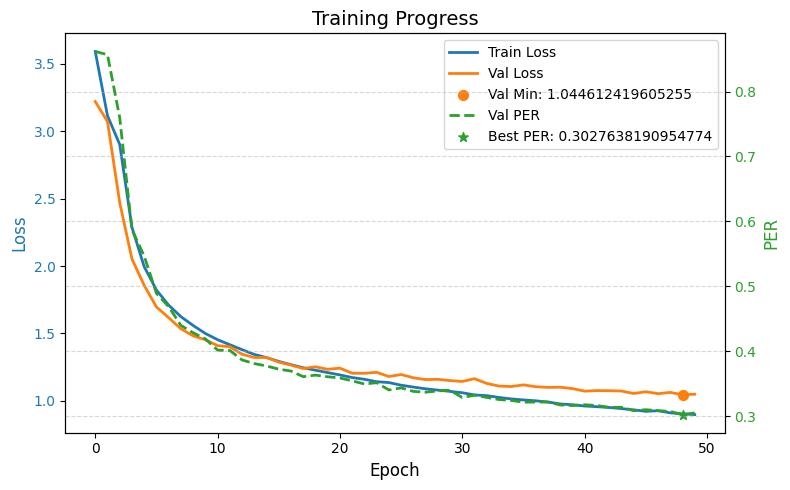

In [15]:
import matplotlib.pyplot as plt
import numpy as np

min_val_i = np.argmin(val_losses)
best_per_i = np.argmin(val_pers)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(train_losses, label="Train Loss", color="tab:blue", linewidth=2)
ax1.plot(val_losses, label="Val Loss", color="tab:orange", linewidth=2)
ax1.scatter(min_val_i, val_losses[min_val_i], label=f"Val Min: {val_losses[min_val_i]}", 
            color="tab:orange", marker='o', s=50)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", color="tab:blue", fontsize=12)
ax1.tick_params(axis='y', labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(val_pers, label="Val PER", color="tab:green", linewidth=2, linestyle="--")
ax2.scatter(best_per_i, val_pers[best_per_i], label=f"Best PER: {val_pers[best_per_i]}", 
            color="tab:green", marker='*', s=50)
ax2.set_ylabel("PER", color="tab:green", fontsize=12)
ax2.tick_params(axis='y', labelcolor="tab:green")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Training Progress", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [16]:
try:
    num_epochs = len(train_losses)
    
    # Calculate key metrics
    min_val_i = np.argmin(val_losses)
    best_per_i = np.argmin(val_pers)
    
    print(f"{'Epoch':<5} | {'Train Loss':<12} | {'Val Loss':<10} | {'Val PER':<10}")
    print("-" * 43)

    # Iterate through the data and print each row
    for epoch in range(num_epochs):
        # Use f-strings for clean alignment and precision
        print(f"{epoch:<5} | {train_losses[epoch]:<12.6f} | {val_losses[epoch]:<10.6f} | {val_pers[epoch]:<10.6f}")

    print("-" * 43)
    
    # Print the summary statistics
    print(f"Minimum Validation Loss: {val_losses[min_val_i]:.6f} (Epoch {min_val_i})")
    print(f"Best Validation PER:     {val_pers[best_per_i]:.6f} (Epoch {best_per_i})")

except NameError:
    print("Error: Please ensure 'train_losses', 'val_losses', and 'val_pers' are defined and accessible.")
except Exception as e:
    print(f"An error occurred: {e}")


Epoch | Train Loss   | Val Loss   | Val PER   
-------------------------------------------
0     | 3.591897     | 3.220413   | 0.861640  
1     | 3.115170     | 3.071986   | 0.856736  
2     | 2.901904     | 2.469467   | 0.759664  
3     | 2.286825     | 2.052554   | 0.587529  
4     | 1.995195     | 1.856326   | 0.546700  
5     | 1.821993     | 1.695967   | 0.489467  
6     | 1.709336     | 1.616426   | 0.468762  
7     | 1.624412     | 1.533950   | 0.440037  
8     | 1.558566     | 1.481858   | 0.428634  
9     | 1.499431     | 1.452385   | 0.419308  
10    | 1.453084     | 1.409219   | 0.401962  
11    | 1.415922     | 1.400649   | 0.401430  
12    | 1.379127     | 1.345247   | 0.386814  
13    | 1.343905     | 1.321052   | 0.381281  
14    | 1.320674     | 1.321355   | 0.377561  
15    | 1.292011     | 1.286478   | 0.372632  
16    | 1.267736     | 1.264544   | 0.369757  
17    | 1.245214     | 1.239360   | 0.361060  
18    | 1.226870     | 1.252337   | 0.363476  
19    | 1.209071

# Final Evaluation

In [17]:
def levenshtein_align(pred, true):
    """
    Returns lists of aligned pairs (p, t) where:
      p = predicted phoneme or None (for deletion)
      t = true phoneme or None (for insertion)
    """
    import numpy as np

    n, m = len(pred), len(true)
    dp = np.zeros((n+1, m+1), dtype=int)

    # initialize borders
    for i in range(1, n+1): dp[i, 0] = i
    for j in range(1, m+1): dp[0, j] = j

    # fill DP matrix
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if pred[i-1] == true[j-1] else 1
            dp[i, j] = min(
                dp[i-1, j] + 1,        # deletion
                dp[i, j-1] + 1,        # insertion
                dp[i-1, j-1] + cost    # match/substitution
            )

    # backtrace
    i, j = n, m
    alignment = []
    while i > 0 or j > 0:
        if i > 0 and dp[i, j] == dp[i-1, j] + 1:
            alignment.append((pred[i-1], None))
            i -= 1
        elif j > 0 and dp[i, j] == dp[i, j-1] + 1:
            alignment.append((None, true[j-1]))
            j -= 1
        else:
            alignment.append((pred[i-1], true[j-1]))
            i -= 1
            j -= 1

    return alignment[::-1]

def plot_confusion_matrix(cm, phoneme_labels=None, normalize="true"):
    """
    Visualize a phoneme confusion matrix.

    Args:
        cm (Tensor or ndarray): Confusion matrix (pred x true)
        phoneme_labels (list of str): Optional list mapping class IDs → phoneme symbols.
                                      Length must be num_classes+1 (including blank at index 0).
        normalize:
            None        → raw counts
            "true"      → normalize each column (per true phoneme)
            "pred"      → normalize each row (per predicted phoneme)
            "all"       → normalize entire matrix
    """
    import seaborn as sns

    cm = cm.cpu().numpy() if hasattr(cm, "cpu") else cm

    # normalization
    cm_norm = cm.astype(float)
    if normalize == "true":
        cm_norm = cm_norm / (cm_norm.sum(axis=1, keepdims=True) + 1e-9)
    elif normalize == "pred":
        cm_norm = cm_norm / (cm_norm.sum(axis=0, keepdims=True) + 1e-9)
    elif normalize == "all":
        cm_norm = cm_norm / cm_norm.sum()

    # labels
    if phoneme_labels is None:
        phoneme_labels = [f"{i}" for i in range(cm.shape[0])]
    else:
        print(f'len phon: {len(phoneme_labels)}, cm.shape[0]: {cm.shape[0]}')
        assert len(phoneme_labels) == cm.shape[0], \
            "phoneme_labels must have length num_classes+1 (including blank=0)."

    plt.figure(figsize=(14, 12))

    sns.heatmap(
        cm_norm,
        square=True,
        cmap="viridis",
        xticklabels=phoneme_labels,
        yticklabels=phoneme_labels,
        cbar=True,
        linewidths=0.05
    )

    plt.title("Phoneme Confusion Matrix")
    plt.xlabel("Predicted phoneme")
    plt.ylabel("True phoneme")
    plt.tight_layout()
    plt.show()


def final_evaluation(model: nn.Module, testing_dataloader: DataLoader, device: torch.device):
    """
    Evaluate the best model on the testing set and compute:
      - CTC loss
      - PER
      - Full phoneme confusion matrix

    model.num_classes must be defined (excluding blank).
    """

    model.eval()
    ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)

    total_loss = 0
    total_edit_distance = 0
    total_phonemes = 0

    # Confusion matrix: rows = predicted, columns = true
    num_classes = model.n_classes   # e.g., 39 phoneme classes (blank=0)
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)

    with torch.no_grad():
        pbar = tqdm(testing_dataloader, desc="Final Evaluation", leave=True)

        for batch in pbar:
            features = batch["input_features"].to(device)
            labels = batch["seq_class_ids"].to(device)
            n_time_steps = batch["n_time_steps"].to(device)
            phone_seq_lens = batch["phone_seq_lens"].to(device)
            day_indicies = batch["day_idxs"].to(device)

            # smoothing for consistency
            features_smooth = gauss_smooth(
                features,
                device,
                smooth_kernel_std=2,
                smooth_kernel_size=100,
                padding="valid",
            )
            if isinstance(model,EEGConformer):
                adjusted_lens = (n_time_steps - 100 + 1) // model.time_pool
            else:
                adjusted_lens = n_time_steps - 100 + 1

            # forward pass
            logits = model(features_smooth, day_idx=day_indicies)

            log_probs = logits.log_softmax(2).permute(1, 0, 2)
            loss = ctc_loss(log_probs, labels, adjusted_lens, phone_seq_lens)
            total_loss += loss.item()

            # sequence-level evaluation
            for i in range(logits.shape[0]):

                # CTC greedy decode
                pred_seq = torch.argmax(logits[i, : adjusted_lens[i]], dim=-1)
                pred_seq = torch.unique_consecutive(pred_seq)
                pred_seq = pred_seq[pred_seq != 0]  # remove CTC blank
                pred_seq = pred_seq.cpu().tolist()

                # true sequence
                true_seq = labels[i, : phone_seq_lens[i]].cpu().tolist()

                # edit distance
                edit_dist = edit_distance(
                    np.array(pred_seq), np.array(true_seq)
                )
                total_edit_distance += edit_dist
                total_phonemes += len(true_seq)

                # update confusion matrix
                alignment = levenshtein_align(pred_seq, true_seq)
                for p, t in alignment:
                    if t is None:
                        cm[0, p] += 1      # deletion
                    elif p is None:
                        cm[t, 0] += 1      # insertion
                    else:
                        cm[t, p] += 1      # match/substitution

            current_per = (
                total_edit_distance / total_phonemes if total_phonemes > 0 else 0
            )
            pbar.set_postfix({"PER": f"{current_per:.4f}"})

    avg_loss = total_loss / len(testing_dataloader)
    per = total_edit_distance / total_phonemes

    return avg_loss, per, cm

In [18]:
phoneme_labels = [
    "BLANK", # for CTC loss
    "SIL",  # silence
    "AA", "AE", "AH","AO", "AW", "AY",
    "B", "CH", "D", "DH", "EH", "ER",
    "EY", "F", "G", "HH", "IH", "IY",
    "JH", "K", "L", "M", "N", "NG",
    "OW", "OY", "P", "R", "S", "SH",
    "T", "TH", "UH", "UW", "V", "W",
    "Y", "Z", "ZH",
]

PatchEmbedding with 13 layers


Final Evaluation: 100%|██████████| 45/45 [00:56<00:00,  1.26s/it, PER=0.3028]


Test CTC Loss: 1.044612419605255
Test PER: 0.3027638190954774
Confusion matrix shape: torch.Size([40, 40])
len phon: 40, cm.shape[0]: 40


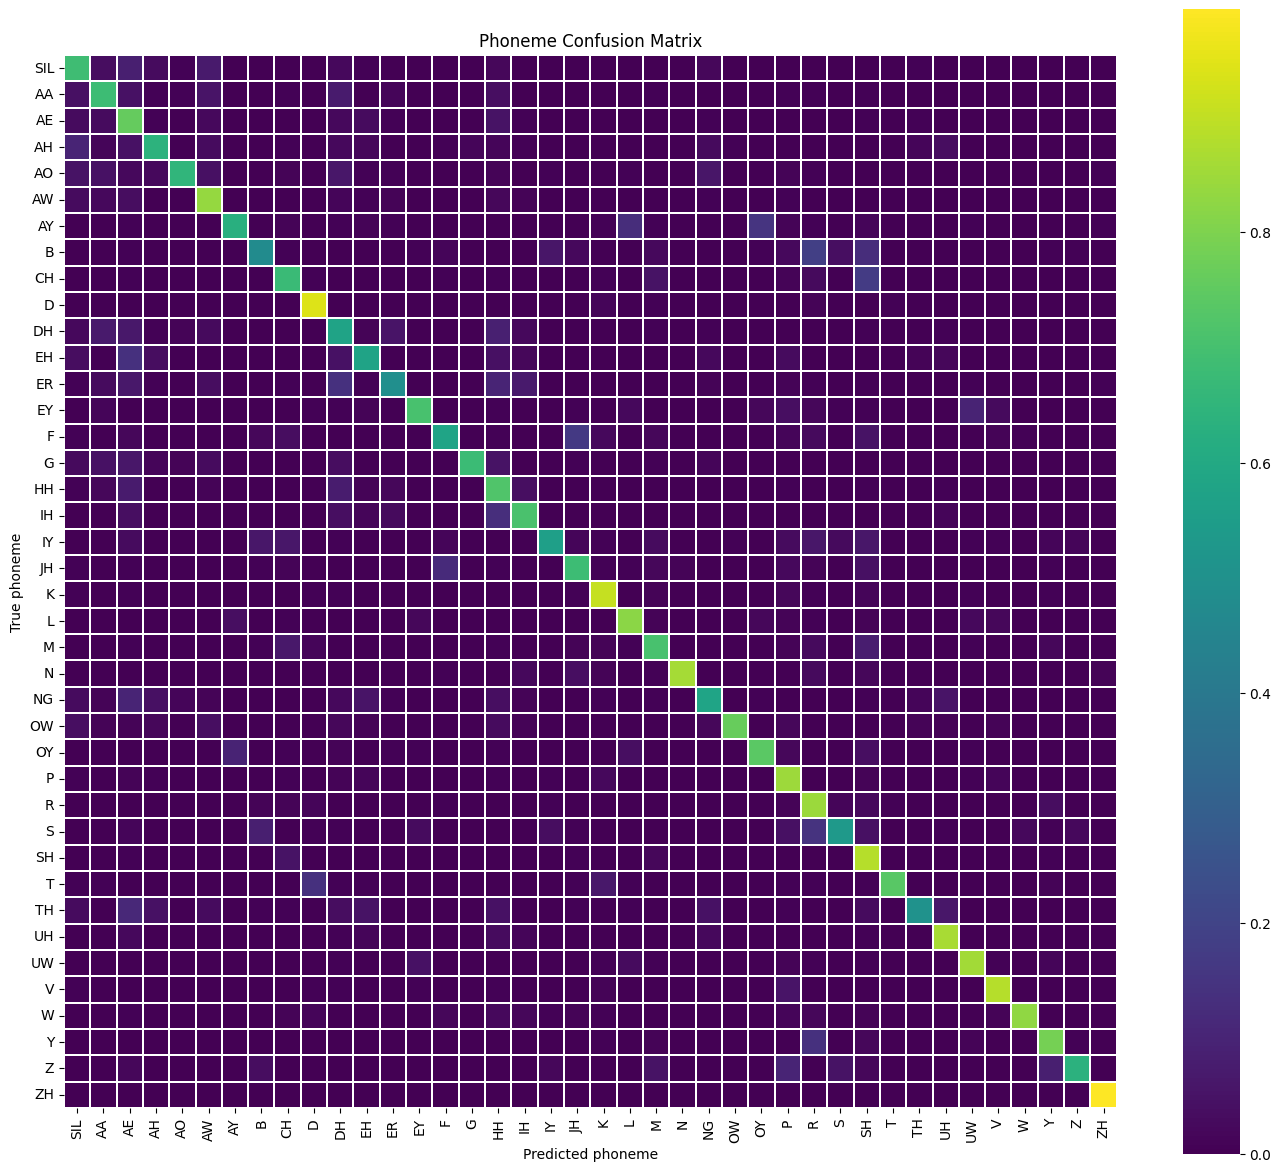

In [19]:
best_model = EEGConformer(
    neural_dim=512,
    d_model=128,
    nhead=4,
    num_encoder_layers=2,
    dim_feedforward=256,
    dropout=0.1,
    n_days=45,
    n_classes=41,
    time_pool=4,
    kernel_size=[9,7,5,3,3],
).to(device)

checkpoint = torch.load("/kaggle/working/best_model.pt", weights_only=False)  # include metadata
best_model.load_state_dict(checkpoint["model_state_dict"])

avg_loss, per, cm = final_evaluation(best_model, val_loader, device)

# Optionally remove the BLANK class from the confusion matrix and labels
# Note: BLANK (index 0) is still included in CTC loss calculations,
#       but we may want to exclude it from visualization for clarity
trim_BLANK = True
if trim_BLANK:
    cm_ = cm[1:, 1:].clone()
    phoneme_labels_ = phoneme_labels[1:] 
else:
    cm_ = cm.clone()
    phoneme_labels_ = phoneme_labels.copy()

# cm_trimmed = cm[1:,1:] #remove blank for insertion/deletion
print("Test CTC Loss:", avg_loss)
print("Test PER:", per)
print("Confusion matrix shape:", cm_.shape)

plot_confusion_matrix(cm_, phoneme_labels_)

In [20]:
import torch
import gc

torch.cuda.empty_cache()
gc.collect()

print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  53494 KiB |   1129 MiB |  32512 GiB |  32512 GiB |
|       from large pool |  35760 KiB |   1121 MiB |  32322 GiB |  32322 GiB |
|       from small pool |  17734 KiB |     25 MiB |    190 GiB |    190 GiB |
|---------------------------------------------------------------------------|
| Active memory         |  53494 KiB |   1129 MiB |  32512 GiB |  32512 GiB |
|       from large pool |  35760 KiB |   1121 MiB |  32322 GiB |